## AirFly Insights: Data Visualization and Analysis of Airline Operations (Milestone2)

### Univariate, Bivariate Analysis and Delay Analysis:-

In [1]:
#Importing all the libraries:-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#As the datatypes are not saved for the cleaned dataset in Python, :.Creating a use_datatypes funtion:-
def use_datatypes(df):
    data['FL_DATE']=pd.to_datetime(data['FL_DATE'])
    data['CANCELLED']=data['CANCELLED'].astype('int8')
    data['DIVERTED']=data['DIVERTED'].astype('int8')
    catg_col=['AIRLINE','AIRLINE_DOT','AIRLINE_CODE','ORIGIN','ORIGIN_CITY','DEST','DEST_CITY','CANCELLATION_CODE']
    for col in catg_col:
        data[col]=data[col].astype('category')
    minu_col=['DEP_DELAY','ARR_DELAY','TAXI_IN','TAXI_OUT','CRS_ELAPSED_TIME','ELAPSED_TIME','AIR_TIME','DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
    for col in minu_col:
        data[col]=data[col].astype('float32')
    hhmm_col=['CRS_DEP_TIME','DEP_TIME','CRS_ARR_TIME','ARR_TIME','WHEELS_OFF','WHEELS_ON']
    for col in hhmm_col:
        data[col]=data[col].astype('Int32')
    data['DISTANCE']=data['DISTANCE'].astype('float32')
    data['DOT_CODE']=data['DOT_CODE'].astype('int32')
    data['FL_NUMBER']=data['FL_NUMBER'].astype('int32')
    data['DEP_HOUR']=data['DEP_HOUR'].astype('Int8')
    data['ROUTE']=data['ROUTE'].astype('category')
    data['YEAR']=data['YEAR'].astype('int32')
    data['MONTH']=data['MONTH'].astype('int8')
    data['MONTH_NAME']=data['MONTH_NAME'].astype('category')
    data['WEEKDAY']=data['WEEKDAY'].astype('category')
    return df

In [3]:
data=pd.read_csv('cleaned_flights_sample.csv')
data.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,MONTH_NAME,WEEKDAY,DEP_HOUR,ROUTE
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,0.0,0.0,0.0,2019,1,January,Wednesday,11,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,0.0,0.0,0.0,2022,11,November,Saturday,21,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,0.0,0.0,0.0,2022,7,July,Friday,10,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,24.0,0.0,0.0,2023,3,March,Monday,16,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,0.0,0.0,0.0,2020,2,February,Sunday,18,MCO-DFW


In [4]:
data=use_datatypes(data)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999984 entries, 0 to 2999983
Data columns (total 38 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             In

#### Percentage of Cancelled VS Not Cancelled flights:-

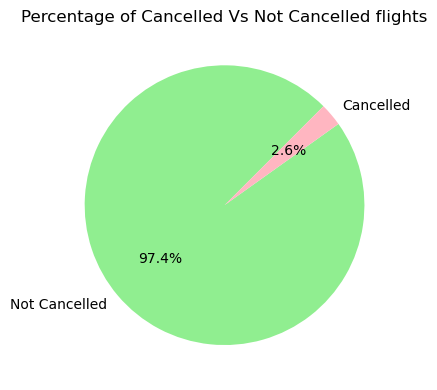

From the above chart, Not Cancelled flights are 97.4% and Cancelled flights are 2.6%.


In [7]:
cancel_counts=data['CANCELLED'].value_counts()
labels=['Not Cancelled','Cancelled']
plt.figure(figsize=(6,4))
plt.pie(cancel_counts,labels=labels,autopct='%1.1f%%',startangle=45,colors=['lightgreen','lightpink'])
plt.title('Percentage of Cancelled Vs Not Cancelled flights')
plt.tight_layout()
plt.show()
print('From the above chart, Not Cancelled flights are 97.4% and Cancelled flights are 2.6%.')

In [8]:
#Analysing the flights which take off as well as they are not diverted, means they reach at their destination
active_flights=data[(data['CANCELLED']==0) & (data['DIVERTED']==0)]
len(active_flights)

2913802

#### Top Airlines by Number of flights (not cancelled and not diverted):-

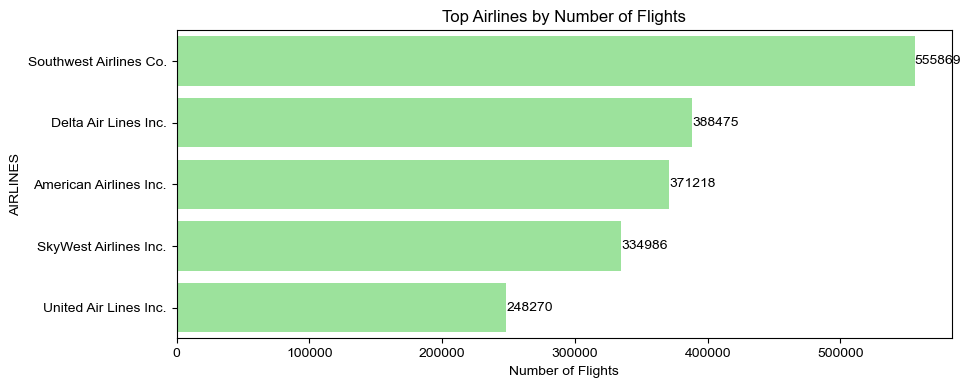

The above chart shows the Top 5 Airlines in the dataset with Southwest Airlines Co. at the top with ~5 lakhs flights.


In [9]:
top_airlines=active_flights['AIRLINE'].value_counts().head(5)
plt.figure(figsize=(10,4))
i=sns.barplot(x=top_airlines.values,y=top_airlines.index,order=top_airlines.index,color='lightgreen')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('Number of Flights')
plt.ylabel('AIRLINES')
plt.title('Top Airlines by Number of Flights')
sns.set_style('white')
plt.show()
print('The above chart shows the Top 5 Airlines in the dataset with Southwest Airlines Co. at the top with ~5 lakhs flights.')

#### Busiest Months:-

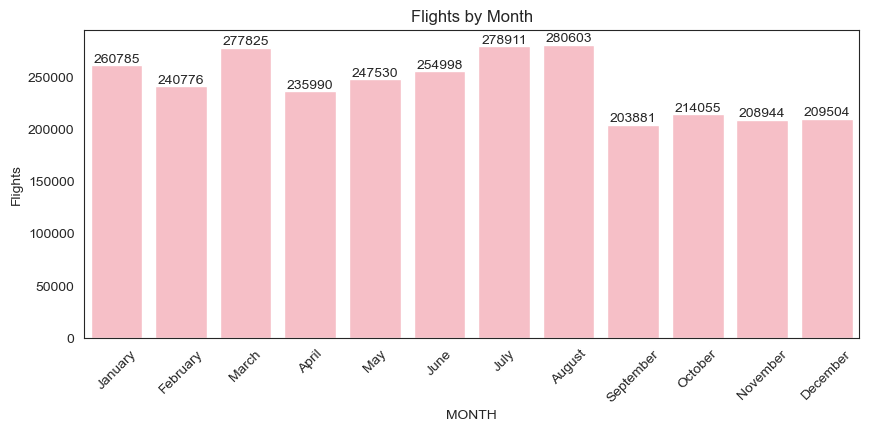

The bar chart shows that the month of August, July and March were the busiest months and September with least flights.


In [10]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts=active_flights['MONTH_NAME'].value_counts().reindex(month_order)
plt.figure(figsize=(10,4))
i=sns.barplot(x=month_counts.index,y=month_counts.values,color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Flights by Month')
plt.xlabel('MONTH')
plt.ylabel('Flights')
plt.xticks(rotation=45)
plt.show()
print('The bar chart shows that the month of August, July and March were the busiest months and September with least flights.')

#### Year with most flights:-

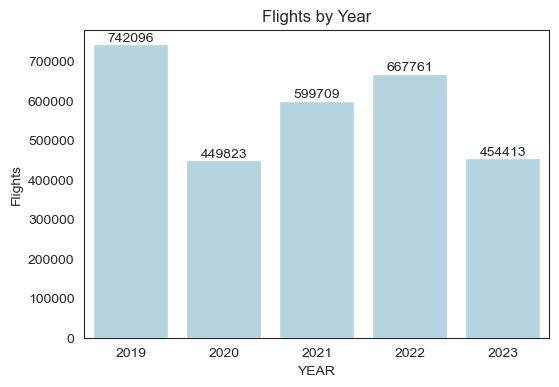

The year 2019 was having the most flights (~7 lakh flights), 2020 and 2023 were having the least number of flights that took off.


In [14]:
year_counts=active_flights['YEAR'].value_counts().sort_index()
plt.figure(figsize=(6,4))
i=sns.barplot(x=year_counts.index,y=year_counts.values,color='lightblue')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Flights by Year')
plt.xlabel('YEAR')
plt.ylabel('Flights')
plt.show()
print('The year 2019 was having the most flights (~7 lakh flights), 2020 and 2023 were having the least number of flights that took off.')

#### Busiest Weekday:-

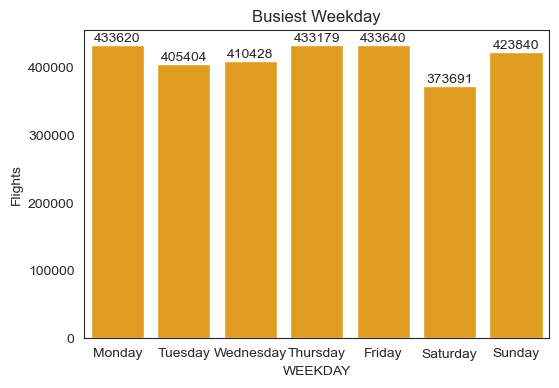

The busisest weekday is Friday, Monday and  Thursday, the month which was not that busy is Saturday.


In [17]:
weekday_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts=active_flights['WEEKDAY'].value_counts().sort_index()
plt.figure(figsize=(6,4))
i=sns.barplot(x=weekday_counts.index,y=weekday_counts.values,order=weekday_order,color='orange')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Busiest Weekday')
plt.xlabel('WEEKDAY')
plt.ylabel('Flights')
plt.show()
print('The busisest weekday is Friday, Monday and  Thursday, the month which was not that busy is Saturday.')

##### ALL the above charts shows the flights which were not cancelled and not diverted, basically means they took off and landed at their scheduled destination.

#### What are the reasons for delay?

#### Top 10 Airlines which got most delayed flights:-

In [19]:
delayed_flights=active_flights[active_flights['ARR_DELAY']>0]  #The delayed flights, arr_delay>0

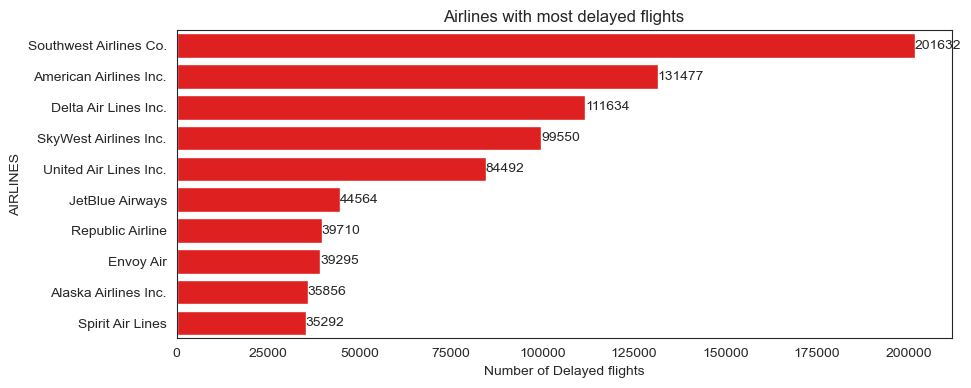

Southwest Airlines Co. is the Airline with most delays.


In [23]:
delayed_airlines=delayed_flights['AIRLINE'].value_counts().head(10)
plt.figure(figsize=(10,4))
i=sns.barplot(x=delayed_airlines.values,y=delayed_airlines.index,order=delayed_airlines.index,color='red')
plt.xlabel('Number of Delayed flights')
plt.ylabel('AIRLINES')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Airlines with most delayed flights')
plt.show()
print('Southwest Airlines Co. is the Airline with most delays.')

#### Average Delay by the Airlines (in mins):-

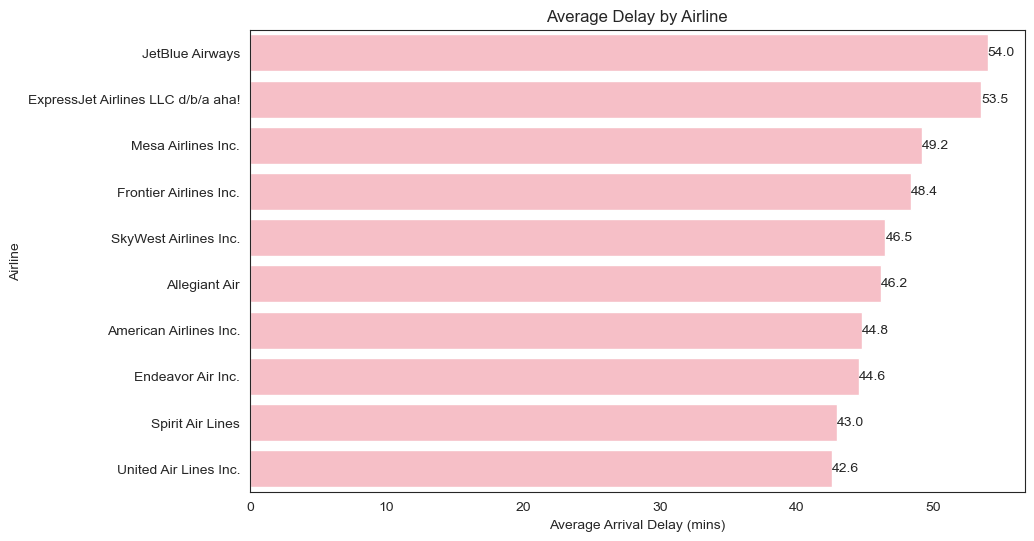

The Average delay is maximum for JetBlue Airways and Express.Jet Airlines LLC d/b/a aha! with delay of 54.0 mins and 53.5 mins.


In [24]:
avg_delay_airline = delayed_flights.groupby('AIRLINE',observed=True)['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
i=sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index,order=avg_delay_airline.index,color='lightpink')
for bars in i.containers:
    i.bar_label(bars,fmt='%1.1f')
plt.xlabel("Average Arrival Delay (mins)")
plt.ylabel("Airline")
plt.title("Average Delay by Airline")
plt.show()
print('The Average delay is maximum for JetBlue Airways and Express.Jet Airlines LLC d/b/a aha! with delay of 54.0 mins and 53.5 mins.')

#### Average Delay by Reasons:-

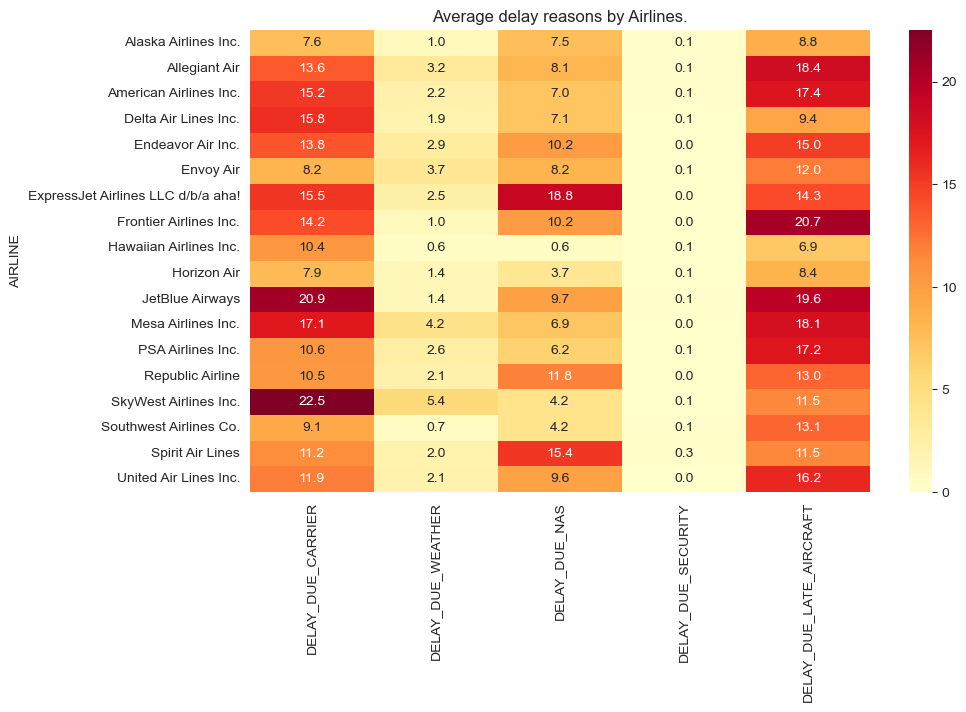

As we know that JetBlue Airways has maximum avg delay, most delay is due to the Carrier and late aircraft, SkyWest Airlines also was delayed the most because of Carrier, Express.Jet Airlines LLC d/b/a aha! has the most delays due to NAS the reason must be air traffic and congestion and Frontier Airlines Inc. delayed the most due to late aircraft.


In [25]:
delay_reason_airline=delayed_flights.groupby('AIRLINE',observed=True)[['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(delay_reason_airline,cmap='YlOrRd',annot=True,fmt='.1f')
plt.title('Average delay reasons by Airlines.')
plt.show()
print('As we know that JetBlue Airways has maximum avg delay, most delay is due to the Carrier and late aircraft, SkyWest Airlines also was delayed the most because of Carrier, Express.Jet Airlines LLC d/b/a aha! has the most delays due to NAS the reason must be air traffic and congestion and Frontier Airlines Inc. delayed the most due to late aircraft.')

#### Airlines with more diversions:-

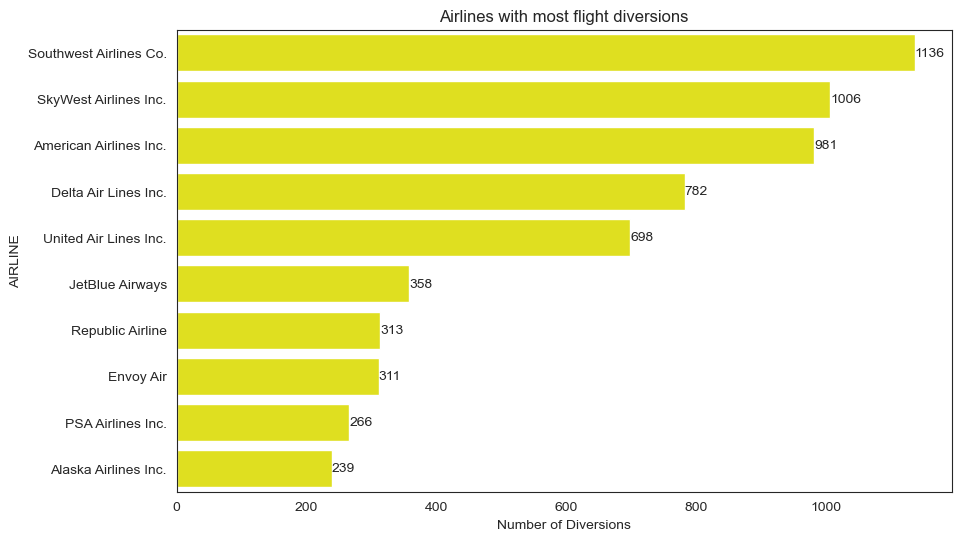

The above chart shows the airlines whose flights diverted the most, did not landed at the scheduled airport.


In [29]:
diverted_airlines=data[data['DIVERTED']==1]['AIRLINE'].value_counts().head(10)
plt.figure(figsize=(10,6))
i=sns.barplot(x=diverted_airlines.values,y=diverted_airlines.index,order=diverted_airlines.index,color='yellow')
plt.xlabel('Number of Diversions')
plt.ylabel('AIRLINE')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Airlines with most flight diversions')
plt.show()
print('The above chart shows the airlines whose flights diverted the most, did not landed at the scheduled airport.')

In [31]:
active_flights['ROUTE']=active_flights['ROUTE'].astype('str')

#### Most Visited Routes:-

In [32]:
top_dest=(active_flights['ROUTE'].value_counts().nlargest(5).reset_index())
top_dest.columns=['ROUTE','COUNT']
top_dest

,ROUTE,COUNT
0,SFO-LAX,5218
1,LAX-SFO,5072
2,OGG-HNL,4589
3,LAX-LAS,4540
4,LGA-ORD,4510


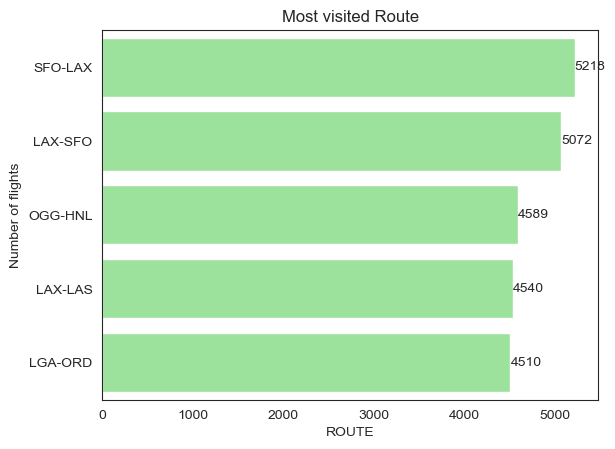

Route SFO-LAX and LAX-SFO is the most visited route. SFO(San Francisco) and LAX(Los Angeles)


In [36]:
i=sns.barplot(x='COUNT',y='ROUTE',data=top_dest,color='lightgreen')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('ROUTE')
plt.ylabel('Number of flights')
plt.title('Most visited Route')
plt.show()
print('Route SFO-LAX and LAX-SFO is the most visited route. SFO(San Francisco) and LAX(Los Angeles)')